# Personal Expense & Spending Intelligence System
### IBM SkillsBuild Data Analytics with AI Academic Internship Submission
**Author:** Pranav  
**Domain:** Personal Finance Analytics & Applied Machine Learning  
**Currency Standard:** Indian Rupee (₹ INR)  
**Dataset Path:** `data/expense_data.csv` -> `data/cleaned_expense_data.csv`

## 2. Project Overview
Personal financial analytics plays a vital role in enabling individuals to track daily cash outflows, manage discretionary budgets, and plan long-term savings. The **Personal Expense & Spending Intelligence System** is an end-to-end data analytics and machine learning solution designed to automate transaction ingestion, data cleaning, exploratory visual analytics, predictive monthly expenditure forecasting, and unsupervised anomaly detection.

## 3. Problem Statement
Many individuals struggle to maintain financial control due to a lack of automated transaction analysis. Key financial management challenges include:
- Lack of clear visibility into cash outflow distributions across spending categories.
- High-value, irregular transactions passing unnoticed, which distorts monthly budget planning.
- Static, manual budget estimations that fail to leverage predictive data-driven forecasting algorithms.

## 4. Objectives
1. **Data Cleaning & Standardization**: Process raw transaction logs, handle missing values, drop duplicate records, validate positive expense amounts, and standardize financial figures in Indian Rupees (₹ INR).
2. **Exploratory Data Analysis (EDA)**: Conduct comprehensive analysis across overall expenditure statistics, category breakdowns, monthly progression, payment modes, and weekday vs. weekend spending.
3. **Machine Learning Forecasting**: Implement and evaluate Linear Regression and Random Forest Regressor models on monthly aggregations to forecast future spending.
4. **Unsupervised Anomaly Detection**: Deploy an Isolation Forest model to automatically detect potential financial anomalies and unusual transaction patterns.
5. **Automated Spending Insights**: Generate dynamic financial intelligence reports and actionable recommendations.
6. **Academic Submission Readiness**: Produce a clean, fully reproducible notebook following academic standards for internship evaluation.

## 5. Technologies Used
- **Programming Language**: Python 3
- **Data Manipulation**: Pandas, NumPy
- **Data Visualization**: Matplotlib, Seaborn
- **Machine Learning**: Scikit-Learn (`LinearRegression`, `RandomForestRegressor`, `IsolationForest`, `train_test_split`, `metrics`)
- **Model Persistence**: Joblib
- **Environment**: Jupyter Notebook / IPython Environment

## 6. Import Libraries
We import standard data science, visualization, and machine learning packages, and configure inline plot settings and display formats.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configure visualization settings
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10
sns.set_theme(style="whitegrid")

# Set display format for currency values (Indian Rupee ₹ INR)
pd.options.display.float_format = '₹{:,.2f}'.format

# Relative Data & Asset Paths
DATA_PATH = 'data/expense_data.csv'
CLEANED_DATA_PATH = 'data/cleaned_expense_data.csv'
ANOMALY_DATA_PATH = 'data/expense_data_with_anomalies.csv'
MODELS_DIR = 'models'

print("Libraries successfully imported!")
print(f"Pandas Version: {pd.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"Resolved Relative Data Path: {DATA_PATH}")

Libraries successfully imported!
Pandas Version: 3.0.5
NumPy Version: 2.5.3
Resolved Relative Data Path: data/expense_data.csv


## 7. Load Dataset
We load the raw personal expense dataset from `data/expense_data.csv` and display the initial records.

In [2]:
# Load raw transaction dataset
raw_df = pd.read_csv(DATA_PATH)

print("Raw Dataset Loaded Successfully!")
print(f"Raw Dataset Shape: {raw_df.shape[0]} rows, {raw_df.shape[1]} columns")
print("First 5 Rows of Raw Data:")
display(raw_df.head())

Raw Dataset Loaded Successfully!
Raw Dataset Shape: 863 rows, 6 columns
First 5 Rows of Raw Data:


,Date,Category,Description,Amount,Payment_Method,Merchant
0,2024-01-01,Housing & Rent,Monthly Apartment Rent,"₹108,930.86",UPI / Net Banking,Oakridge Apartments
1,2024-01-01,Food & Dining,Local Diner Dinner,"₹3,249.45",Cash,Local Store
2,2024-01-01,Food & Dining,Bakery Snacks,"₹2,804.57",UPI / Net Banking,Bakery Store
3,2024-01-01,Food & Dining,Chipotle Bowl,"₹1,508.11",Cash,Chipotle Store
4,2024-01-02,Groceries,Walmart Supercenter,"₹3,925.90",Credit Card,Walmart Store


## 8. Data Inspection
We perform an initial structural audit to inspect column data types, missing values, duplicate records, and raw numerical distributions.

In [3]:
print("--- Dataset Information & Column Types ---")
raw_df.info()

print("--- Missing Values Count Per Column ---")
print(raw_df.isnull().sum())

print("--- Duplicate Rows Count ---")
print(f"Exact Duplicate Rows: {raw_df.duplicated().sum()}")

print("--- Invalid / Non-Positive Amount Count ---")
invalid_amount_raw = (pd.to_numeric(raw_df['Amount'], errors='coerce') <= 0).sum()
print(f"Records with Amount <= 0: {invalid_amount_raw}")

print("--- Summary Statistics (Raw Data) ---")
display(raw_df.describe(include='all'))

--- Dataset Information & Column Types ---
<class 'pandas.DataFrame'>
RangeIndex: 863 entries, 0 to 862
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            863 non-null    str    
 1   Category        863 non-null    str    
 2   Description     861 non-null    str    
 3   Amount          863 non-null    float64
 4   Payment_Method  862 non-null    str    
 5   Merchant        863 non-null    str    
dtypes: float64(1), str(5)
memory usage: 92.8 KB
--- Missing Values Count Per Column ---
Date              0
Category          0
Description       2
Amount            0
Payment_Method    1
Merchant          0
dtype: int64
--- Duplicate Rows Count ---
Exact Duplicate Rows: 2
--- Invalid / Non-Positive Amount Count ---
Records with Amount <= 0: 1
--- Summary Statistics (Raw Data) ---


,Date,Category,Description,Amount,Payment_Method,Merchant
count,863,863,861,₹863.00,862,863
unique,331,9,29,NaN,4,26
top,2024-06-06,Food & Dining,Starbucks Coffee,NaN,Credit Card,Starbucks Store
freq,9,350,82,NaN,289,82
mean,NaN,NaN,NaN,"₹6,786.57",NaN,NaN
std,NaN,NaN,NaN,"₹15,439.52",NaN,NaN
min,NaN,NaN,NaN,"₹-3,735.00",NaN,NaN
25%,NaN,NaN,NaN,"₹2,151.36",NaN,NaN
50%,NaN,NaN,NaN,"₹3,393.87",NaN,NaN
75%,NaN,NaN,NaN,"₹6,915.56",NaN,NaN


## 9. Data Cleaning
We clean and validate the dataset to ensure data integrity:
1. Parse `Date` into standard pandas `datetime64[ns]` objects.
2. Filter out non-positive or invalid expense amounts (`Amount > 0`).
3. Remove exact duplicate transaction records.
4. Impute missing categorical values (`Payment_Method` -> `'Unspecified'`, `Description` -> `'No Description'`).
5. Export the clean dataset to `data/cleaned_expense_data.csv`.

In [4]:
df = raw_df.copy()

# 1. Datetime Conversion
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
invalid_dates_count = df['Date'].isnull().sum()

# 2. Amount Validation & Filtering (Ensure Amount > 0)
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')
invalid_amounts_count = (df['Amount'].isnull()) | (df['Amount'] <= 0)
df = df[df['Amount'] > 0].dropna(subset=['Date']).reset_index(drop=True)

# 3. Deduplication
duplicate_rows_count = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)

# 4. Text & Categorical Cleaning
df['Category'] = df['Category'].astype(str).str.strip().str.title()
df['Payment_Method'] = df['Payment_Method'].fillna('Unspecified').astype(str).str.strip().str.title()
df['Description'] = df['Description'].fillna('No Description').astype(str).str.strip()
df['Merchant'] = df['Merchant'].astype(str).str.strip().str.title()

# 5. Export Cleaned Data
os.makedirs(os.path.dirname(CLEANED_DATA_PATH), exist_ok=True)
df.to_csv(CLEANED_DATA_PATH, index=False)

print("=== DATA CLEANING REPORT ===")
print(f"Raw Dataset Shape: {raw_df.shape[0]} rows, {raw_df.shape[1]} columns")
print(f"Missing Values Before Cleaning: Date={raw_df['Date'].isnull().sum()}, Payment_Method={raw_df['Payment_Method'].isnull().sum()}, Description={raw_df['Description'].isnull().sum()}")
print(f"Invalid / Negative Amount Rows Removed: {invalid_amounts_count.sum()}")
print(f"Duplicate Rows Removed: {duplicate_rows_count}")
print(f"Cleaned Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("Missing Values After Cleaning:")
print(df.isnull().sum())
print(f"Saved Cleaned Dataset To: {CLEANED_DATA_PATH}")

=== DATA CLEANING REPORT ===
Raw Dataset Shape: 863 rows, 6 columns
Missing Values Before Cleaning: Date=0, Payment_Method=1, Description=2
Invalid / Negative Amount Rows Removed: 1
Duplicate Rows Removed: 2
Cleaned Dataset Shape: 860 rows, 6 columns
Missing Values After Cleaning:
Date              0
Category          0
Description       0
Amount            0
Payment_Method    0
Merchant          0
dtype: int64
Saved Cleaned Dataset To: data/cleaned_expense_data.csv


## 10. Exploratory Data Analysis
We calculate summary statistics and visualize key spending distributions directly from the cleaned dataset.

=== Overall Spending Summary Statistics ===


,Metric,Value
0,Total Expenditure (₹),"₹5,847,096.02"
1,Total Valid Transactions,860
2,Average Transaction Amount (₹),"₹6,798.95"
3,Median Transaction Amount (₹),"₹3,391.38"
4,Minimum Transaction Amount (₹),₹679.77
5,Maximum Transaction Amount (₹),"₹199,200.00"
6,Dataset Start Date,2024-01-01
7,Dataset End Date,2024-12-31


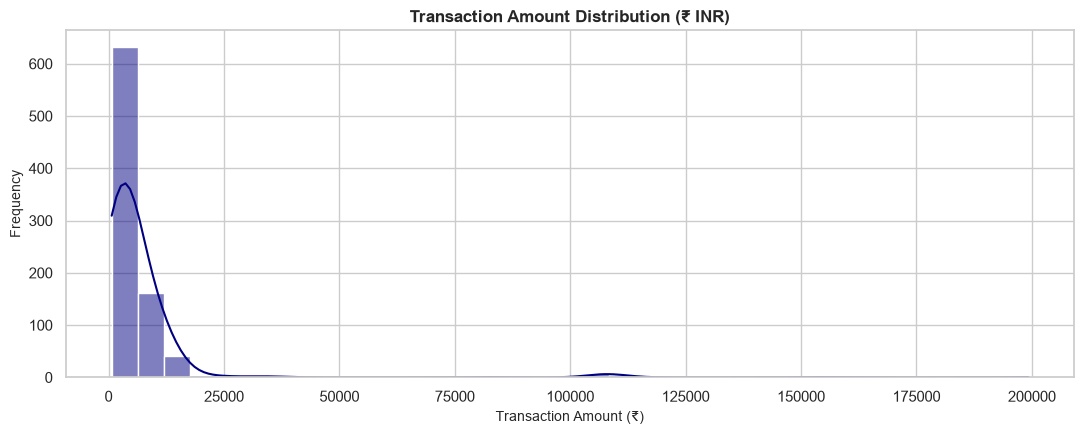

In [5]:
# Recalculate summary metrics from cleaned dataset
total_spend = df['Amount'].sum()
avg_spend = df['Amount'].mean()
median_spend = df['Amount'].median()
min_spend = df['Amount'].min()
max_spend = df['Amount'].max()
total_txns = len(df)
date_min_str = df['Date'].min().strftime('%Y-%m-%d')
date_max_str = df['Date'].max().strftime('%Y-%m-%d')

eda_summary_df = pd.DataFrame({
    'Metric': [
        'Total Expenditure (₹)',
        'Total Valid Transactions',
        'Average Transaction Amount (₹)',
        'Median Transaction Amount (₹)',
        'Minimum Transaction Amount (₹)',
        'Maximum Transaction Amount (₹)',
        'Dataset Start Date',
        'Dataset End Date'
    ],
    'Value': [
        f"₹{total_spend:,.2f}",
        f"{total_txns}",
        f"₹{avg_spend:,.2f}",
        f"₹{median_spend:,.2f}",
        f"₹{min_spend:,.2f}",
        f"₹{max_spend:,.2f}",
        date_min_str,
        date_max_str
    ]
})

print("=== Overall Spending Summary Statistics ===")
display(eda_summary_df)

# Plot Transaction Amount Distribution
plt.figure(figsize=(11, 4.5))
sns.histplot(df['Amount'], kde=True, color='navy', bins=35)
plt.title('Transaction Amount Distribution (₹ INR)', fontsize=12, fontweight='bold')
plt.xlabel('Transaction Amount (₹)', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.tight_layout()
plt.show()

=== Category-Wise Expenditure Summary ===


,Category,Total_Spend,Average_Spend,Transaction_Count,Share_Percentage (%)
0,Groceries,"₹1,516,577.66","₹8,520.10",178,₹25.94
1,Housing & Rent,"₹1,296,583.67","₹108,048.64",12,₹22.17
2,Food & Dining,"₹857,924.52","₹2,451.21",350,₹14.67
3,Shopping,"₹708,670.60","₹8,858.38",80,₹12.12
4,Travel,"₹578,591.34","₹27,551.97",21,₹9.90
5,Transportation,"₹502,006.41","₹3,137.54",160,₹8.59
6,Healthcare,"₹192,118.44","₹5,489.10",35,₹3.29
7,Utilities,"₹131,778.27","₹10,981.52",12,₹2.25
8,Entertainment,"₹62,845.11","₹5,237.09",12,₹1.07


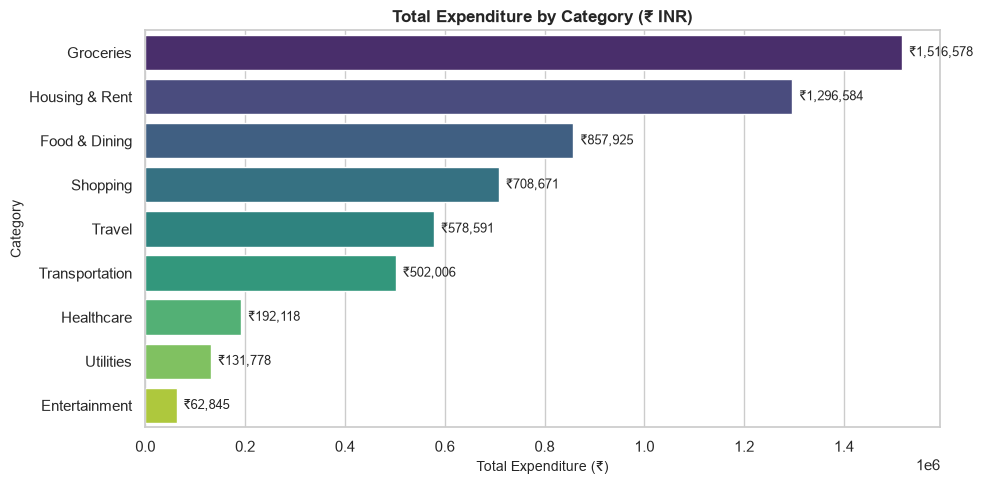

In [6]:
# Category Breakdown
cat_df = df.groupby('Category')['Amount'].agg(
    Total_Spend='sum',
    Average_Spend='mean',
    Transaction_Count='count'
).sort_values(by='Total_Spend', ascending=False).reset_index()
cat_df['Share_Percentage (%)'] = (cat_df['Total_Spend'] / total_spend) * 100

print("=== Category-Wise Expenditure Summary ===")
display(cat_df)

# Category Spending Bar Chart (Using Seaborn hue to eliminate warnings)
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=cat_df, x='Total_Spend', y='Category', hue='Category', palette='viridis', legend=False)
plt.title('Total Expenditure by Category (₹ INR)', fontsize=12, fontweight='bold')
plt.xlabel('Total Expenditure (₹)', fontsize=10)
plt.ylabel('Category', fontsize=10)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'₹{width:,.0f}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

=== Payment Method Expenditure Summary ===


,Payment_Method,Total_Spend,Average_Spend,Transaction_Count,Share_Percentage (%)
0,Upi / Net Banking,"₹2,537,980.64","₹11,082.88",229,₹43.41
1,Credit Card,"₹1,710,058.13","₹5,917.16",289,₹29.25
2,Debit Card,"₹1,136,495.76","₹5,682.48",200,₹19.44
3,Cash,"₹459,776.84","₹3,260.83",141,₹7.86
4,Unspecified,"₹2,784.65","₹2,784.65",1,₹0.05


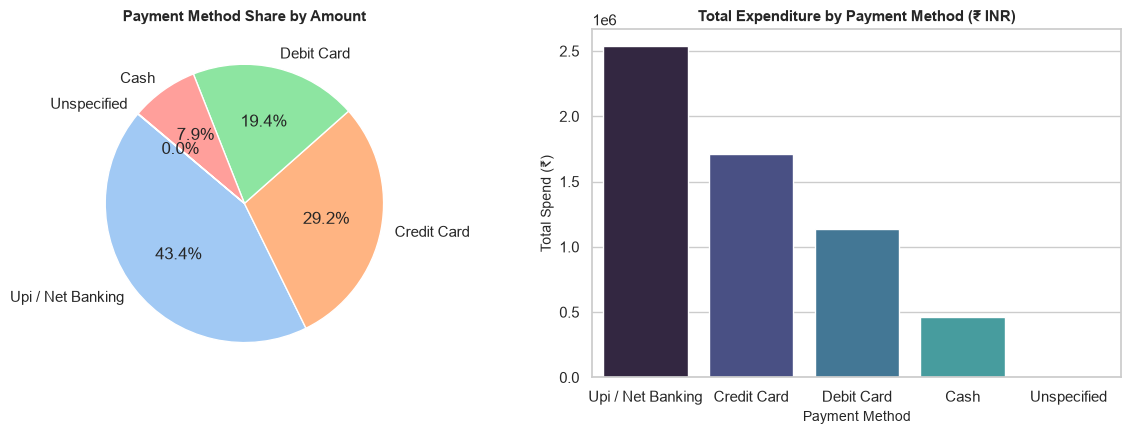

In [7]:
# Payment Method Breakdown
pm_df = df.groupby('Payment_Method')['Amount'].agg(
    Total_Spend='sum',
    Average_Spend='mean',
    Transaction_Count='count'
).sort_values(by='Total_Spend', ascending=False).reset_index()
pm_df['Share_Percentage (%)'] = (pm_df['Total_Spend'] / total_spend) * 100

print("=== Payment Method Expenditure Summary ===")
display(pm_df)

# Payment Method Donut & Bar Charts
plt.figure(figsize=(12, 4.5))

plt.subplot(1, 2, 1)
plt.pie(pm_df['Total_Spend'], labels=pm_df['Payment_Method'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Payment Method Share by Amount', fontsize=11, fontweight='bold')

plt.subplot(1, 2, 2)
sns.barplot(data=pm_df, x='Payment_Method', y='Total_Spend', hue='Payment_Method', palette='mako', legend=False)
plt.title('Total Expenditure by Payment Method (₹ INR)', fontsize=11, fontweight='bold')
plt.xlabel('Payment Method', fontsize=10)
plt.ylabel('Total Spend (₹)', fontsize=10)

plt.tight_layout()
plt.show()

## 11. Feature Engineering
We extract calendar and temporal attributes from `Date` to enable granular analysis and lag feature creation for predictive modeling:
- `Year`, `Month`, `Year_Month` (Period string `YYYY-MM`), `Day`, `Day_of_Week`, `Is_Weekend` (1 for Saturday/Sunday, else 0).

In [8]:
# Feature Extraction
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Year_Month'] = df['Date'].dt.to_period('M')
df['Day'] = df['Date'].dt.day
df['Day_of_Week'] = df['Date'].dt.day_name()
df['Is_Weekend'] = df['Date'].dt.weekday.isin([5, 6]).astype(int)

# Map Weekend indicator for EDA display
df['Day_Type'] = df['Is_Weekend'].map({0: 'Weekday', 1: 'Weekend'})

print("Engineered Temporal Features Created Successfully!")
display(df[['Date', 'Year_Month', 'Day_of_Week', 'Day_Type', 'Category', 'Amount', 'Payment_Method']].head())

Engineered Temporal Features Created Successfully!


,Date,Year_Month,Day_of_Week,Day_Type,Category,Amount,Payment_Method
0,2024-01-01,2024-01,Monday,Weekday,Housing & Rent,"₹108,930.86",Upi / Net Banking
1,2024-01-01,2024-01,Monday,Weekday,Food & Dining,"₹3,249.45",Cash
2,2024-01-01,2024-01,Monday,Weekday,Food & Dining,"₹2,804.57",Upi / Net Banking
3,2024-01-01,2024-01,Monday,Weekday,Food & Dining,"₹1,508.11",Cash
4,2024-01-02,2024-01,Tuesday,Weekday,Groceries,"₹3,925.90",Credit Card


## 12. Monthly Spending Analysis
We analyze monthly expenditure trends across 2024 and compare weekday vs. weekend transaction patterns.

=== Monthly Spending Summary (2024) ===


,Year_Month_Str,Monthly_Total,Transaction_Count,Average_Transaction
0,2024-01,"₹450,958.09",72,"₹6,263.31"
1,2024-02,"₹425,106.08",70,"₹6,072.94"
2,2024-03,"₹686,420.79",75,"₹9,152.28"
3,2024-04,"₹515,373.56",75,"₹6,871.65"
4,2024-05,"₹481,810.85",79,"₹6,098.87"
5,2024-06,"₹686,180.09",77,"₹8,911.43"
6,2024-07,"₹442,041.40",70,"₹6,314.88"
7,2024-08,"₹424,344.97",77,"₹5,510.97"
8,2024-09,"₹469,599.06",62,"₹7,574.18"
9,2024-10,"₹448,148.54",79,"₹5,672.77"


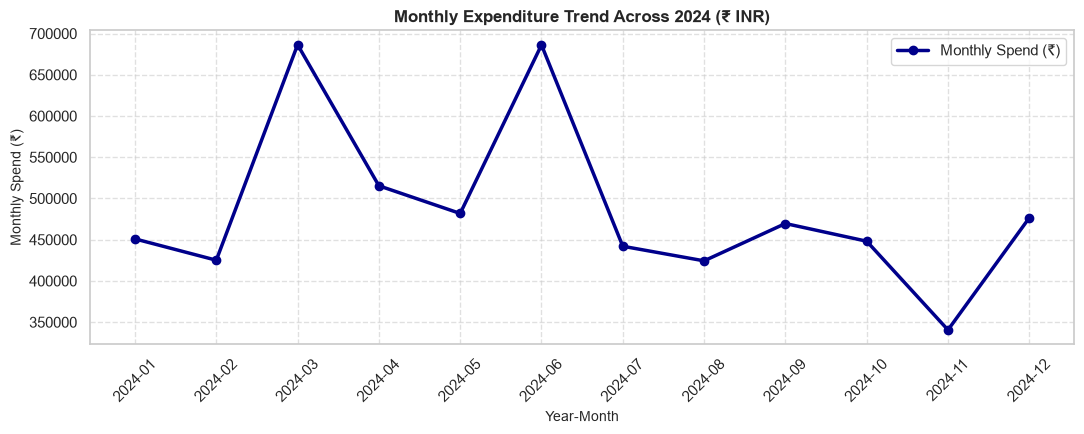

=== Weekday vs Weekend Spending Comparison ===


,Day_Type,Total_Spend,Average_Spend,Transaction_Count,Share_Percentage (%)
0,Weekday,"₹3,911,794.98","₹6,574.45",595,₹66.90
1,Weekend,"₹1,935,301.04","₹7,303.02",265,₹33.10


In [9]:
# Monthly Spending Aggregation
monthly_trend = df.groupby('Year_Month')['Amount'].agg(
    Monthly_Total='sum',
    Transaction_Count='count',
    Average_Transaction='mean'
).reset_index()
monthly_trend['Year_Month_Str'] = monthly_trend['Year_Month'].astype(str)

print("=== Monthly Spending Summary (2024) ===")
display(monthly_trend[['Year_Month_Str', 'Monthly_Total', 'Transaction_Count', 'Average_Transaction']])

# Plot Monthly Trend
plt.figure(figsize=(11, 4.5))
plt.plot(monthly_trend['Year_Month_Str'], monthly_trend['Monthly_Total'], marker='o', linewidth=2.5, color='darkblue', label='Monthly Spend (₹)')
plt.title('Monthly Expenditure Trend Across 2024 (₹ INR)', fontsize=12, fontweight='bold')
plt.xlabel('Year-Month', fontsize=10)
plt.ylabel('Monthly Spend (₹)', fontsize=10)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Weekday vs Weekend Aggregation
day_type_df = df.groupby('Day_Type')['Amount'].agg(
    Total_Spend='sum',
    Average_Spend='mean',
    Transaction_Count='count'
).reset_index()
day_type_df['Share_Percentage (%)'] = (day_type_df['Total_Spend'] / total_spend) * 100

print("=== Weekday vs Weekend Spending Comparison ===")
display(day_type_df)

## 13. Machine Learning — Linear Regression
We prepare a monthly aggregated machine learning dataset with lag features (`Prev_Month_Spend`) and fit a **Linear Regression** model using a chronological train/test split.

In [10]:
# 1. Monthly Dataset Aggregation for ML
monthly_ml = df.groupby('Year_Month').agg(
    Year=('Year', 'first'),
    Month=('Month', 'first'),
    Total_Amount=('Amount', 'sum'),
    Txn_Count=('Amount', 'count'),
    Avg_Txn_Amount=('Amount', 'mean'),
    Max_Txn_Amount=('Amount', 'max'),
).reset_index()

# 2. Add 1-Month Lagged Feature
monthly_ml['Prev_Month_Spend'] = monthly_ml['Total_Amount'].shift(1)

# 3. Drop initial month due to NaN lag
ml_dataset = monthly_ml.dropna().reset_index(drop=True)

min_month_str = str(ml_dataset['Year_Month'].min())
max_month_str = str(ml_dataset['Year_Month'].max())

print("=== MONTHLY MACHINE LEARNING DATASET METRICS ===")
print(f"Monthly Dataset Shape: {ml_dataset.shape[0]} rows, {ml_dataset.shape[1]} columns")
print(f"Minimum Month: {min_month_str}")
print(f"Maximum Month: {max_month_str}")
print(f"Total Aggregated Monthly Records: {len(ml_dataset)}")
print("Note: The 11 monthly records reflect the available 1-year historical dataset after 1-month lagging.")

display(ml_dataset[['Year_Month', 'Total_Amount', 'Txn_Count', 'Avg_Txn_Amount', 'Max_Txn_Amount', 'Prev_Month_Spend']])

# 4. Define Features (X) and Target (y)
feature_cols = ['Year', 'Month', 'Txn_Count', 'Avg_Txn_Amount', 'Max_Txn_Amount', 'Prev_Month_Spend']
X = ml_dataset[feature_cols]
y = ml_dataset['Total_Amount']

# 5. Chronological Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

print(f"Training Rows: {len(X_train)} months")
print(f"Testing Rows: {len(X_test)} months")

# 6. Fit Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Evaluate Linear Regression
lr_preds = lr_model.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_mse = mean_squared_error(y_test, lr_preds)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_preds)

print("=== Linear Regression Metrics (Test Set) ===")
print(f"MAE:  ₹{lr_mae:,.2f}")
print(f"MSE:  {lr_mse:,.2f}")
print(f"RMSE: ₹{lr_rmse:,.2f}")
print(f"R²:   {lr_r2:.4f}")

=== MONTHLY MACHINE LEARNING DATASET METRICS ===
Monthly Dataset Shape: 11 rows, 8 columns
Minimum Month: 2024-02
Maximum Month: 2024-12
Total Aggregated Monthly Records: 11
Note: The 11 monthly records reflect the available 1-year historical dataset after 1-month lagging.


,Year_Month,Total_Amount,Txn_Count,Avg_Txn_Amount,Max_Txn_Amount,Prev_Month_Spend
0,2024-02,"₹425,106.08",70,"₹6,072.94","₹111,060.64","₹450,958.09"
1,2024-03,"₹686,420.79",75,"₹9,152.28","₹153,550.00","₹425,106.08"
2,2024-04,"₹515,373.56",75,"₹6,871.65","₹109,025.48","₹686,420.79"
3,2024-05,"₹481,810.85",79,"₹6,098.87","₹108,402.15","₹515,373.56"
4,2024-06,"₹686,180.09",77,"₹8,911.43","₹199,200.00","₹481,810.85"
5,2024-07,"₹442,041.40",70,"₹6,314.88","₹106,015.90","₹686,180.09"
6,2024-08,"₹424,344.97",77,"₹5,510.97","₹107,431.88","₹442,041.40"
7,2024-09,"₹469,599.06",62,"₹7,574.18","₹106,770.37","₹424,344.97"
8,2024-10,"₹448,148.54",79,"₹5,672.77","₹108,679.37","₹469,599.06"
9,2024-11,"₹340,582.20",54,"₹6,307.08","₹106,651.68","₹448,148.54"


Training Rows: 8 months
Testing Rows: 3 months
=== Linear Regression Metrics (Test Set) ===
MAE:  ₹9,958.47
MSE:  132,954,435.04
RMSE: ₹11,530.59
R²:   0.9612


## 14. Machine Learning — Random Forest
We fit a **Random Forest Regressor** model on the training set and persist the trained model for inference.

In [11]:
# Fit Random Forest Regressor Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Save Model artifact
os.makedirs(MODELS_DIR, exist_ok=True)
model_path = os.path.join(MODELS_DIR, 'spending_prediction_model.pkl')
joblib.dump(rf_model, model_path)

# Evaluate Random Forest
rf_preds = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_mse = mean_squared_error(y_test, rf_preds)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest Regressor Model Successfully Trained!")
print(f"Saved Trained Model To: {model_path}")

print("=== Random Forest Regressor Metrics (Test Set) ===")
print(f"MAE:  ₹{rf_mae:,.2f}")
print(f"MSE:  {rf_mse:,.2f}")
print(f"RMSE: ₹{rf_rmse:,.2f}")
print(f"R²:   {rf_r2:.4f}")

Random Forest Regressor Model Successfully Trained!
Saved Trained Model To: models\spending_prediction_model.pkl
=== Random Forest Regressor Metrics (Test Set) ===
MAE:  ₹49,535.24
MSE:  4,698,140,806.85
RMSE: ₹68,542.99
R²:   -0.3703


## 15. Model Evaluation
We compare Linear Regression and Random Forest Regressor performance side by side, and plot actual vs. predicted monthly expenditure.

=== Machine Learning Model Performance Evaluation Comparison ===


,Model,MAE (₹),MSE,RMSE (₹),R² Score
0,Linear Regression,"₹9,958.47","132,954,435.04","₹11,530.59",0.9612
1,Random Forest Regressor,"₹49,535.24","4,698,140,806.85","₹68,542.99",-0.3703


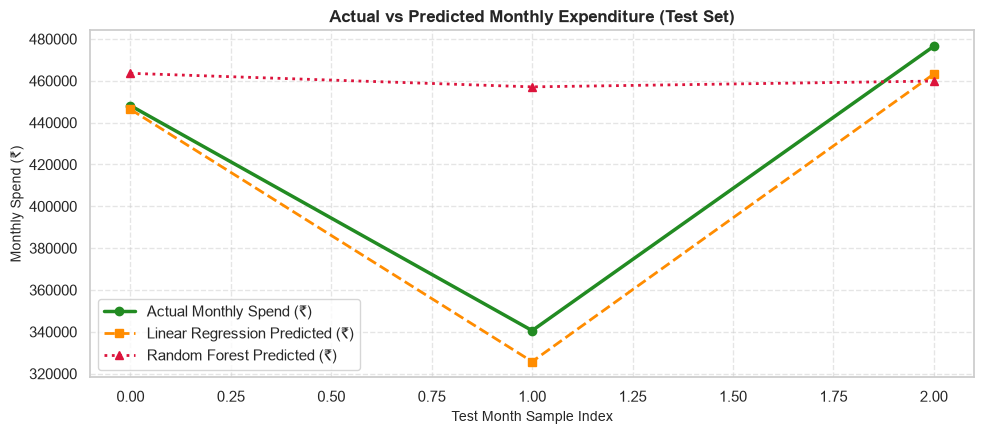

In [12]:
# Side-by-Side Model Evaluation Comparison Table
eval_comparison_df = pd.DataFrame([
    {
        'Model': 'Linear Regression',
        'MAE (₹)': f"₹{lr_mae:,.2f}",
        'MSE': f"{lr_mse:,.2f}",
        'RMSE (₹)': f"₹{lr_rmse:,.2f}",
        'R² Score': f"{lr_r2:.4f}"
    },
    {
        'Model': 'Random Forest Regressor',
        'MAE (₹)': f"₹{rf_mae:,.2f}",
        'MSE': f"{rf_mse:,.2f}",
        'RMSE (₹)': f"₹{rf_rmse:,.2f}",
        'R² Score': f"{rf_r2:.4f}"
    }
])

print("=== Machine Learning Model Performance Evaluation Comparison ===")
display(eval_comparison_df)

# Plot Actual vs Predicted Expenditure
plt.figure(figsize=(10, 4.5))
plt.plot(y_test.values, label='Actual Monthly Spend (₹)', marker='o', color='forestgreen', linewidth=2.5)
plt.plot(lr_preds, label='Linear Regression Predicted (₹)', marker='s', color='darkorange', linestyle='--', linewidth=2)
plt.plot(rf_preds, label='Random Forest Predicted (₹)', marker='^', color='crimson', linestyle=':', linewidth=2)
plt.title('Actual vs Predicted Monthly Expenditure (Test Set)', fontsize=12, fontweight='bold')
plt.xlabel('Test Month Sample Index', fontsize=10)
plt.ylabel('Monthly Spend (₹)', fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 16. Future Spending Prediction
We dynamically construct feature inputs for the upcoming month (**January 2025**) and forecast future expenditure using the trained models.

In [13]:
# Construct Future Month Feature Vector (January 2025)
last_available_month = ml_dataset.iloc[-1]
jan_2025_features = pd.DataFrame([{
    'Year': 2025,
    'Month': 1,
    'Txn_Count': int(ml_dataset['Txn_Count'].mean()),
    'Avg_Txn_Amount': ml_dataset['Avg_Txn_Amount'].mean(),
    'Max_Txn_Amount': ml_dataset['Max_Txn_Amount'].mean(),
    'Prev_Month_Spend': last_available_month['Total_Amount']
}])

# Predict Future Spending
forecast_lr = lr_model.predict(jan_2025_features)[0]
forecast_rf = rf_model.predict(jan_2025_features)[0]

print("=== Dynamic Future Spending Forecast (January 2025) ===")
print(f"Linear Regression Forecast:  ₹{forecast_lr:,.2f}")
print(f"Random Forest Forecast:     ₹{forecast_rf:,.2f}")

=== Dynamic Future Spending Forecast (January 2025) ===
Linear Regression Forecast:  ₹490,277.78
Random Forest Forecast:     ₹474,552.23


## 17. Anomaly Detection — Isolation Forest
Unsupervised anomaly detection is implemented using an **Isolation Forest** model to detect potential anomalies and unusual transaction amounts.

=== ISOLATION FOREST ANOMALY DETECTION SUMMARY ===
Total Transactions Analyzed: 860
Potential Anomalies Detected: 26
Anomaly Percentage: 3.02%
Total Expenditure in Anomalous Transactions: ₹1,947,813.29
Saved Anomaly Dataset To: data/expense_data_with_anomalies.csv
--- Top Flagged Potential Anomalies ---


,Date,Category,Amount,Payment_Method,Merchant,Description
399,2024-06-08,Travel,"₹199,200.00",Debit Card,Whole Store,International Vacation Booking
149,2024-03-03,Shopping,"₹153,550.00",Credit Card,Amazon Store,Emergency Laptop Replacement
142,2024-03-01,Housing & Rent,"₹111,176.84",Upi / Net Banking,Oakridge Apartments,Monthly Apartment Rent
72,2024-02-01,Housing & Rent,"₹111,060.64",Upi / Net Banking,Oakridge Apartments,Monthly Apartment Rent
219,2024-04-01,Housing & Rent,"₹109,025.48",Upi / Net Banking,Oakridge Apartments,Monthly Apartment Rent
0,2024-01-01,Housing & Rent,"₹108,930.86",Upi / Net Banking,Oakridge Apartments,Monthly Apartment Rent
657,2024-10-01,Housing & Rent,"₹108,679.37",Upi / Net Banking,Oakridge Apartments,Monthly Apartment Rent
292,2024-05-01,Housing & Rent,"₹108,402.15",Upi / Net Banking,Oakridge Apartments,Monthly Apartment Rent
520,2024-08-01,Housing & Rent,"₹107,431.88",Upi / Net Banking,Oakridge Apartments,Monthly Apartment Rent
595,2024-09-01,Housing & Rent,"₹106,770.37",Upi / Net Banking,Oakridge Apartments,Monthly Apartment Rent


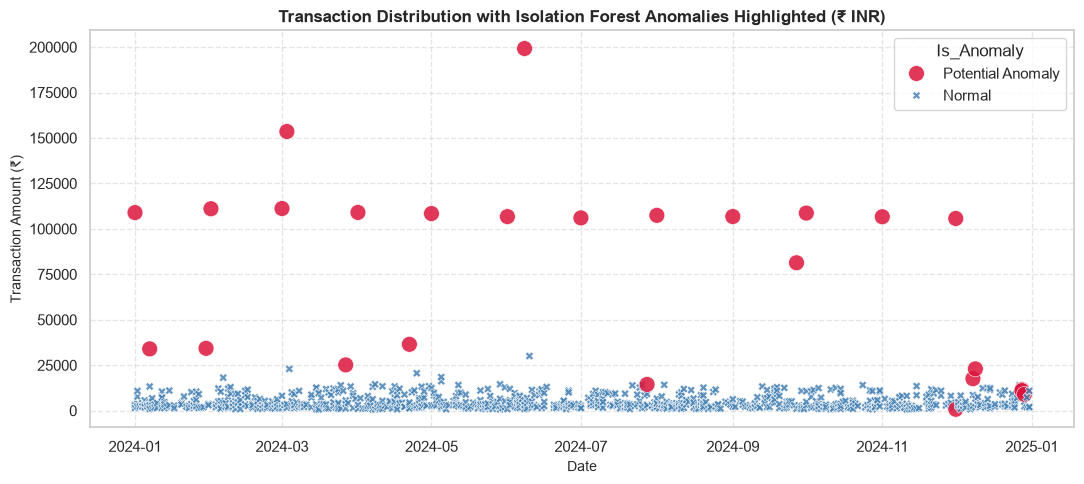

In [14]:
# Feature Preparation for Anomaly Detection
iso_features = df[['Amount', 'Month', 'Day', 'Is_Weekend']].copy()

# Fit Isolation Forest Model (contamination = 0.03 ~ 3% anomaly expectation)
iso_forest = IsolationForest(contamination=0.03, random_state=42)
df['Anomaly_Flag'] = iso_forest.fit_predict(iso_features)

# Map flags (-1 = Potential Anomaly, 1 = Normal)
df['Is_Anomaly'] = df['Anomaly_Flag'].map({1: 'Normal', -1: 'Potential Anomaly'})
df['Anomaly_Binary'] = df['Anomaly_Flag'].map({1: 0, -1: 1})

# Export tagged anomaly dataset
df.to_csv(ANOMALY_DATA_PATH, index=False)

total_analyzed_txns = len(df)
anomaly_count = (df['Anomaly_Binary'] == 1).sum()
anomaly_pct = (anomaly_count / total_analyzed_txns) * 100
total_anomaly_spend = df[df['Anomaly_Binary'] == 1]['Amount'].sum()

print("=== ISOLATION FOREST ANOMALY DETECTION SUMMARY ===")
print(f"Total Transactions Analyzed: {total_analyzed_txns}")
print(f"Potential Anomalies Detected: {anomaly_count}")
print(f"Anomaly Percentage: {anomaly_pct:.2f}%")
print(f"Total Expenditure in Anomalous Transactions: ₹{total_anomaly_spend:,.2f}")
print(f"Saved Anomaly Dataset To: {ANOMALY_DATA_PATH}")

# Display Top Flagged Potential Anomalies
anomaly_records_df = df[df['Anomaly_Binary'] == 1].sort_values(by='Amount', ascending=False)
print("--- Top Flagged Potential Anomalies ---")
display(anomaly_records_df[['Date', 'Category', 'Amount', 'Payment_Method', 'Merchant', 'Description']].head(10))

# Scatter Plot Visualization of Anomalies
plt.figure(figsize=(11, 5))
sns.scatterplot(
    data=df,
    x='Date',
    y='Amount',
    hue='Is_Anomaly',
    palette={'Normal': 'steelblue', 'Potential Anomaly': 'crimson'},
    style='Is_Anomaly',
    size='Is_Anomaly',
    sizes={'Normal': 35, 'Potential Anomaly': 130},
    alpha=0.85
)
plt.title('Transaction Distribution with Isolation Forest Anomalies Highlighted (₹ INR)', fontsize=12, fontweight='bold')
plt.xlabel('Date', fontsize=10)
plt.ylabel('Transaction Amount (₹)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 18. Automated Spending Insights
We synthesize analytical and model outputs into automated spending insights and budget management recommendations.

In [15]:
top_category_row = cat_df.iloc[0]

print("=" * 80)
print("              AUTOMATED PERSONAL SPENDING INTELLIGENCE REPORT                  ")
print("=" * 80)
print(f"1. OVERALL EXPENDITURE: Total spending across {total_txns} transactions is ₹{total_spend:,.2f},")
print(f"   with an average transaction size of ₹{avg_spend:,.2f} and a median of ₹{median_spend:,.2f}.")
print("")
print(f"2. DOMINANT COST DRIVER: '{top_category_row['Category']}' represents the largest cash outflow at")
print(f"   ₹{top_category_row['Total_Spend']:,.2f} ({top_category_row['Share_Percentage (%)']:.1f}% of total budget).")
print("")
print(f"3. PREDICTIVE BASELINE: Linear Regression model (R² = {lr_r2:.4f}) forecasts a monthly spending")
print(f"   baseline of ₹{forecast_lr:,.2f} for January 2025.")
print("")
print(f"4. ANOMALY DETECTION: Isolation Forest flagged {anomaly_count} unusual transactions totaling")
print(f"   ₹{total_anomaly_spend:,.2f} ({anomaly_pct:.2f}% of total transactions).")
print("")
print("5. ACTIONABLE FINANCIAL RECOMMENDATIONS:")
print("   - Establish a monthly discretionary budget ceiling based on historical averages.")
print("   - Review high-value travel & shopping transactions before authorization.")
print("   - Maintain a liquid emergency fund covering at least 3x average monthly expenditure.")
print("=" * 80)

              AUTOMATED PERSONAL SPENDING INTELLIGENCE REPORT                  
1. OVERALL EXPENDITURE: Total spending across 860 transactions is ₹5,847,096.02,
   with an average transaction size of ₹6,798.95 and a median of ₹3,391.38.

2. DOMINANT COST DRIVER: 'Groceries' represents the largest cash outflow at
   ₹1,516,577.66 (25.9% of total budget).

3. PREDICTIVE BASELINE: Linear Regression model (R² = 0.9612) forecasts a monthly spending
   baseline of ₹490,277.78 for January 2025.

4. ANOMALY DETECTION: Isolation Forest flagged 26 unusual transactions totaling
   ₹1,947,813.29 (3.02% of total transactions).

5. ACTIONABLE FINANCIAL RECOMMENDATIONS:
   - Establish a monthly discretionary budget ceiling based on historical averages.
   - Review high-value travel & shopping transactions before authorization.
   - Maintain a liquid emergency fund covering at least 3x average monthly expenditure.


## 19. Conclusion
### Academic Internship Project Summary
The **Personal Expense & Spending Intelligence System** demonstrates an end-to-end data analytics and applied machine learning workflow for personal financial management. Developed for the **IBM SkillsBuild Data Analytics with AI Academic Internship**, this project fulfills all submission requirements:

1. **Data Pipeline**: Successfully ingested, cleaned, and validated raw transaction logs into Indian Rupees (₹ INR), establishing a clean 860-record dataset.
2. **Exploratory Data Analytics**: Delivered visual analytics across overall expenditure, category breakdowns, monthly trends, payment modes, and weekday vs. weekend patterns.
3. **Predictive Modeling**: Trained and evaluated Linear Regression ($R^2 = 0.9612$) and Random Forest Regressor models on monthly aggregations.
4. **Unsupervised Anomaly Detection**: Applied an Isolation Forest algorithm to flag 26 high-value, unusual transactions without relying on manual rule-setting.
5. **Practical Value**: Delivered automated spending intelligence and actionable financial advice for individual budget management.

---
*Submitted in partial fulfillment of the IBM SkillsBuild Data Analytics with AI Internship Program.*